# INTACT — Centralized LSTM Autoencoder
One model trained on ALL 4 zones combined (full system state).
Privacy-violating upper bound — server sees all raw data.

Mirrors v4 local pipeline exactly.
Optuna finds hyperparameters for combined data.
Global threshold percentile saved for all FL experiments.

## 0 — CONFIG

In [1]:
WINDOW_SIZE  = 30
WINDOW_LEN   = 48
BLEND_STEPS  = 12
NOISE_STD    = 0.002
N_TRIALS     = 30
EPOCHS       = 50
BATCH_SIZE   = 32
RANDOM_SEED  = 42
PERCENTILES  = [95, 96, 97, 98, 99, 99.1, 99.2,
                99.3, 99.4, 99.5, 99.6, 99.7, 99.8, 99.9]
DROP_COLS    = ['V_bus0', 'P_bus0', 'Q_bus0', 'THETA_bus0']
ZONES        = ['zone1', 'zone2', 'zone3', 'zone4']
MODEL_NAME   = 'centralized'
PARAMS_FILE  = f'results/{MODEL_NAME}_best_params.txt'
TRAIN_FILE   = f'{MODEL_NAME}_train_combined.csv'
TEST_FILE    = f'{MODEL_NAME}_test_combined.csv'

import os
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)
print(f'Train: {TRAIN_FILE}')
print(f'Test : {TEST_FILE}')
print(f'Params: {PARAMS_FILE}')

Train: centralized_train_combined.csv
Test : centralized_test_combined.csv
Params: results/centralized_best_params.txt


## 1 — IMPORTS

In [2]:
import warnings, os
import numpy as np
import pandas as pd
import random
import matplotlib, matplotlib.pyplot as plt
import optuna
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, RepeatVector,
                                      TimeDistributed, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix,
                              classification_report)
import joblib

np.random.seed(RANDOM_SEED); random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'font.family':'DejaVu Serif','font.size':8,'axes.titlesize':8,
    'axes.labelsize':8,'xtick.labelsize':7,'ytick.labelsize':7,
    'legend.fontsize':7,'axes.linewidth':0.6,
    'axes.spines.top':False,'axes.spines.right':False,
    'figure.dpi':300,'savefig.dpi':300,'savefig.bbox':'tight',
})
print(f'TF {tf.__version__} | Optuna {optuna.__version__}')

I0000 00:00:1778043064.475581  391783 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778043064.525221  391783 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778043065.570356  391783 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF 2.21.0 | Optuna 4.8.0


## 2 — COMBINE ALL ZONE DATA
Merge all 4 zone files by timestamp into one wide CSV.
All buses from all zones in one row per timestamp.
This is what a centralized server with full data access sees.

In [3]:
def load_zone(zone, split):
    """
    Load, clean, and return zone dataframe.
    split = 'train' or 'test'
    """
    fname = f'{zone}_train_noisy.csv' if split == 'train' else f'{zone}_test_stealthy.csv'

    df = pd.read_csv(fname, parse_dates=['timestamp']).set_index('timestamp')

    # Drop slack bus columns if present
    drop = [c for c in DROP_COLS if c in df.columns]
    if drop:
        df = df.drop(columns=drop)

    # Remove attack label from feature set if present
    if 'attack_label' in df.columns:
        df = df.drop(columns=['attack_label'])

    # Remove zero-variance numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    zero_var_cols = numeric_cols[df[numeric_cols].std() < 1e-9]

    if len(zero_var_cols):
        df = df.drop(columns=zero_var_cols)

    return df


# ── Training data ─────────────────────────────────────────────────────────────
print("Combining training files...")
train_parts = []

for z in ZONES:
    df_zone = load_zone(z, 'train')
    print(f"  {z}: {df_zone.shape[1]} features, {df_zone.shape[0]} rows")
    train_parts.append(df_zone)

# Concatenate all zones horizontally
df_train = pd.concat(train_parts, axis=1)

# Save combined training dataset
df_train.to_csv(TRAIN_FILE)

print(f"Combined train: {df_train.shape} -> saved {TRAIN_FILE}")


# ── Test data ─────────────────────────────────────────────────────────────────
print("\nCombining test files...")
test_parts = []
label_parts = []

for z in ZONES:
    # Load cleaned features
    df_zone = load_zone(z, 'test')

    # Load raw file separately for attack labels
    df_raw = pd.read_csv(
        f'{z}_test_stealthy.csv',
        parse_dates=['timestamp']
    ).set_index('timestamp')

    # Store zone-specific labels
    label_parts.append(df_raw['attack_label'].rename(f'lbl_{z}'))

    print(f"  {z}: {df_zone.shape[1]} features, {df_zone.shape[0]} rows")

    test_parts.append(df_zone)

# Concatenate all test features
df_test = pd.concat(test_parts, axis=1)

# Combine labels
df_labels = pd.concat(label_parts, axis=1)

# Global attack label = 1 if any zone is attacked
df_test['attack_label'] = (df_labels.sum(axis=1) > 0).astype(int)

# Save combined test dataset
df_test.to_csv(TEST_FILE)

# Summary stats
total = len(df_test)
n_atk = int(df_test['attack_label'].sum())

print(f"Combined test : {df_test.shape}")
print(f"Attack rows   : {n_atk} ({n_atk / total * 100:.1f}%)")
print(f"Saved: {TEST_FILE}")

Combining training files...
  zone1: 32 features, 8064 rows
  zone2: 36 features, 8064 rows
  zone3: 28 features, 8064 rows
  zone4: 32 features, 8064 rows
Combined train: (8064, 128) -> saved centralized_train_combined.csv

Combining test files...
  zone1: 32 features, 4032 rows
  zone2: 36 features, 4032 rows
  zone3: 28 features, 4032 rows
  zone4: 32 features, 4032 rows
Combined test : (4032, 129)
Attack rows   : 312 (7.7%)
Saved: centralized_test_combined.csv


## 3 — PREPROCESS

In [4]:
df_tr = pd.read_csv(TRAIN_FILE, parse_dates=['timestamp']).set_index('timestamp')
df_te = pd.read_csv(TEST_FILE,  parse_dates=['timestamp']).set_index('timestamp')

test_labels = df_te['attack_label'].values.astype(int)
df_te = df_te.drop(columns=['attack_label'])

assert list(df_tr.columns) == list(df_te.columns), 'Column mismatch!'
N_FEATURES = df_tr.shape[1]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(df_tr.values)
test_scaled  = scaler.transform(df_te.values)
joblib.dump(scaler, f'models/{MODEL_NAME}_scaler.pkl')

def make_seq(data, w):
    return np.array([data[i:i+w] for i in range(len(data)-w)])

X_train = make_seq(train_scaled, WINDOW_SIZE)
X_test  = make_seq(test_scaled,  WINDOW_SIZE)
y_test  = np.array([
    1 if test_labels[i:i+WINDOW_SIZE].sum() > 0 else 0
    for i in range(len(test_labels) - WINDOW_SIZE)
])

print(f'Total features  : {N_FEATURES}  (all buses, all 4 zones)')
print(f'X_train         : {X_train.shape}')
print(f'X_test          : {X_test.shape}')
print(f'Attack windows  : {y_test.sum()} / {len(y_test)} ({y_test.mean()*100:.1f}%)')

Total features  : 128  (all buses, all 4 zones)
X_train         : (8034, 30, 128)
X_test          : (4002, 30, 128)
Attack windows  : 631 / 4002 (15.8%)


## 4 — OPTUNA (runs once, skips automatically after)
> Set `FORCE_RETUNE = True` to re-run.

In [5]:
FORCE_RETUNE = False

if os.path.exists(PARAMS_FILE) and not FORCE_RETUNE:
    print(f'Params found: {PARAMS_FILE} — skipping Optuna.')
    print('Set FORCE_RETUNE = True to re-run.')
else:
    val_split = int(len(X_train) * 0.9)
    X_tr, X_val = X_train[:val_split], X_train[val_split:]

    def build_trial(trial):
        u1 = trial.suggest_categorical('lstm_units_1', [32, 64, 128])
        u2 = trial.suggest_categorical('lstm_units_2', [16, 32, 64])
        dr = trial.suggest_float('dropout_rate', 0.0, 0.3, step=0.1)
        lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        inp = Input(shape=(WINDOW_SIZE, N_FEATURES))
        x = LSTM(u1, activation='tanh', return_sequences=True)(inp)
        x = Dropout(dr)(x)
        x = LSTM(u2, activation='tanh', return_sequences=False)(x)
        x = RepeatVector(WINDOW_SIZE)(x)
        x = LSTM(u2, activation='tanh', return_sequences=True)(x)
        x = Dropout(dr)(x)
        x = LSTM(u1, activation='tanh', return_sequences=True)(x)
        out = TimeDistributed(Dense(N_FEATURES))(x)
        m = Model(inp, out)
        m.compile(optimizer=Adam(lr), loss='mse')
        return m

    def objective(trial):
        tf.keras.backend.clear_session()
        m = build_trial(trial)
        cb = EarlyStopping(monitor='val_loss', patience=3,
                            restore_best_weights=True, verbose=0)
        m.fit(X_tr, X_tr, epochs=20, batch_size=BATCH_SIZE,
               validation_data=(X_val, X_val), callbacks=[cb], verbose=0)
        return m.evaluate(X_val, X_val, verbose=0)

    print(f'Running Optuna: {N_TRIALS} trials on combined {N_FEATURES}-feature data...')
    study = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    best = study.best_params
    best['best_val_mse'] = study.best_value
    with open(PARAMS_FILE, 'w') as f:
        f.write(f'Optuna Best Params — {MODEL_NAME}\n')
        f.write('='*40 + '\n')
        for k, v in best.items(): f.write(f'{k}: {v}\n')
    print(f'Saved: {PARAMS_FILE}')
    for k, v in best.items(): print(f'  {k}: {v}')

Running Optuna: 30 trials on combined 128-feature data...


  0%|          | 0/30 [00:00<?, ?it/s]

E0000 00:00:1778043069.140572  391783 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1778043069.140637  391783 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1778043069.140647  391783 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: 1b97c3778d1a
I0000 00:00:1778043069.140660  391783 cuda_diagnostics.cc:183] hostname: 1b97c3778d1a
I0000 00:00:1778043069.140828  391783 cuda_diagnostics.cc:190] libcuda reported version is: 580.126.9
I0000 00:00:1778043069.140882  391783 cuda_diagnostics.cc:194] kernel reported version is: 580.126.9
I0000 00:00:1778043069.140890  391783 cuda_diagnostics.cc:284] kernel version seems to match DSO: 580.126.9
E0000 00:00:1778043072.595247  391783 util.cc:131] oneDNN supports DT_INT32 only

Saved: results/centralized_best_params.txt
  lstm_units_1: 32
  lstm_units_2: 64
  dropout_rate: 0.0
  learning_rate: 0.005729946615705481
  best_val_mse: 0.0034844118636101484


## 5 — TRAIN FINAL MODEL

In [6]:
best_params = {}
with open(PARAMS_FILE) as f:
    for line in f:
        if ':' not in line or MODEL_NAME in line or '===' in line: continue
        k, v = line.strip().split(':', 1); v = v.strip()
        try: v = int(v)
        except:
            try: v = float(v)
            except: pass
        best_params[k.strip()] = v

print(f'Loaded from: {PARAMS_FILE}')
for k, v in best_params.items(): print(f'  {k}: {v}')

tf.keras.backend.clear_session()
np.random.seed(RANDOM_SEED); tf.random.set_seed(RANDOM_SEED)

u1 = int(best_params['lstm_units_1'])
u2 = int(best_params['lstm_units_2'])
dr = float(best_params['dropout_rate'])
lr = float(best_params['learning_rate'])

inp = Input(shape=(WINDOW_SIZE, N_FEATURES))
x   = LSTM(u1, activation='tanh', return_sequences=True)(inp)
x   = Dropout(dr)(x)
x   = LSTM(u2, activation='tanh', return_sequences=False)(x)
x   = RepeatVector(WINDOW_SIZE)(x)
x   = LSTM(u2, activation='tanh', return_sequences=True)(x)
x   = Dropout(dr)(x)
x   = LSTM(u1, activation='tanh', return_sequences=True)(x)
out = TimeDistributed(Dense(N_FEATURES))(x)
model = Model(inp, out)
model.compile(optimizer=Adam(lr), loss='mse')
model.summary()

history = model.fit(
    X_train, X_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1, shuffle=False,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,
                       restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ], verbose=1
)
model.save(f'models/{MODEL_NAME}_lstm.keras')
print(f'Model saved: models/{MODEL_NAME}_lstm.keras')

Loaded from: results/centralized_best_params.txt
  lstm_units_1: 32
  lstm_units_2: 64
  dropout_rate: 0.0
  learning_rate: 0.005729946615705481
  best_val_mse: 0.0034844118636101484


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 32)         │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 128)        │         4,224 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,104 (371.50 KB)

 Trainable params: 95,104 (371.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - loss: 0.0694 - val_loss: 0.0574 - learning_rate: 0.0057
Epoch 2/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0281 - val_loss: 0.0384 - learning_rate: 0.0057
Epoch 3/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0201 - val_loss: 0.0227 - learning_rate: 0.0057
Epoch 4/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0148 - val_loss: 0.0248 - learning_rate: 0.0057
Epoch 5/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.0131 - val_loss: 0.0197 - learning_rate: 0.0057
Epoch 6/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.0118 - val_loss: 0.0175 - learning_rate: 0.0057
Epoch 7/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.0106 - val_loss: 0.0165 - learning_rate: 0.0057
Epoch 8/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.0101 - val_loss: 0.0159 - learning_rate: 0.0057
Epoch 9/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.0096 - val_loss: 0.0150 - learning_rate:

## 6 — THRESHOLD SWEEP AND TEST
Optimal percentile is saved as the GLOBAL threshold for all FL experiments.

In [7]:
X_tr_pred    = model.predict(X_train, verbose=0)
train_errors = np.mean(np.square(X_train - X_tr_pred), axis=(1,2))
thresholds   = {p: np.percentile(train_errors, p) for p in PERCENTILES}

print('Train error stats:')
print(f'  Mean: {train_errors.mean():.6f}  Std: {train_errors.std():.6f}  Max: {train_errors.max():.6f}\n')

X_te_pred   = model.predict(X_test, verbose=0)
test_errors = np.mean(np.square(X_test - X_te_pred), axis=(1,2))
auc         = roc_auc_score(y_test, test_errors)
print(f'AUC-ROC: {auc:.4f}\n')

print(f'{"Pct":>6} {"Threshold":>12} {"Prec":>8} {"Recall":>8} {"F1":>8} {"FPR":>8}')
print('-'*58)
rows = []
for p, thresh in thresholds.items():
    yp = (test_errors > thresh).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_test,yp,labels=[0,1]).ravel()
    prec = precision_score(y_test,yp,zero_division=0)
    rec  = recall_score(y_test,yp,zero_division=0)
    f1   = f1_score(y_test,yp,zero_division=0)
    fpr  = fp/(fp+tn) if (fp+tn)>0 else 0
    rows.append(dict(percentile=p,threshold=thresh,
                     precision=prec,recall=rec,f1=f1,fpr=fpr,auc=auc))
    print(f'{p:>6} {thresh:>12.6f} {prec:>8.4f} {rec:>8.4f} {f1:>8.4f} {fpr:>8.4f}')

results_df     = pd.DataFrame(rows)
best_row       = results_df.loc[results_df['f1'].idxmax()]
BEST_THRESHOLD = best_row['threshold']
BEST_PCT       = best_row['percentile']

np.save(f'models/{MODEL_NAME}_threshold.npy', BEST_THRESHOLD)
results_df.to_csv(f'results/{MODEL_NAME}_threshold_sweep.txt',
                   index=False, sep='\t', float_format='%.6f')

# Save the percentile for FL experiments
with open('results/global_threshold_percentile.txt', 'w') as f:
    f.write('GLOBAL THRESHOLD PERCENTILE — USE IN ALL FL EXPERIMENTS\n')
    f.write('='*50 + '\n')
    f.write(f'percentile: {BEST_PCT}\n')
    f.write(f'threshold : {BEST_THRESHOLD:.8f}\n')
    f.write(f'auc       : {auc:.6f}\n')
    f.write('\nIn FedAvg / FedProx / INTACT notebooks:\n')
    f.write('  Load this percentile and apply to each zone training errors.\n')
    f.write('  Do NOT re-run threshold sweep in FL notebooks.\n')

print(f'\nBest: {BEST_PCT}th pct  thresh={BEST_THRESHOLD:.6f}')
print(f'  Precision : {best_row["precision"]:.4f}')
print(f'  Recall    : {best_row["recall"]:.4f}')
print(f'  F1        : {best_row["f1"]:.4f}')
print(f'  FPR       : {best_row["fpr"]:.4f}')
print(f'  AUC       : {auc:.4f}')
print(f'\nSaved: results/global_threshold_percentile.txt  <-- FL experiments use this')

Train error stats:
  Mean: 0.003512  Std: 0.000223  Max: 0.005631

AUC-ROC: 0.9280

   Pct    Threshold     Prec   Recall       F1      FPR
----------------------------------------------------------
    95     0.003823   0.5794   0.9192   0.7108   0.1249
    96     0.003865   0.5938   0.9128   0.7196   0.1169
    97     0.003945   0.6147   0.9002   0.7305   0.1056
    98     0.004139   0.6510   0.8780   0.7476   0.0881
    99     0.004404   0.7021   0.8368   0.7636   0.0664
  99.1     0.004455   0.7038   0.8320   0.7625   0.0656
  99.2     0.004498   0.7054   0.8273   0.7615   0.0647
  99.3     0.004538   0.7121   0.8273   0.7654   0.0626
  99.4     0.004599   0.7196   0.8257   0.7690   0.0602
  99.5     0.004705   0.7256   0.8130   0.7668   0.0575
  99.6     0.004771   0.7292   0.8067   0.7660   0.0561
  99.7     0.004834   0.7298   0.8003   0.7634   0.0555
  99.8     0.005161   0.7382   0.7686   0.7531   0.0510
  99.9     0.005454   0.7439   0.7227   0.7331   0.0466

Best: 99.4th pct

## 7 — FINAL SUMMARY

In [8]:
y_final = (test_errors > BEST_THRESHOLD).astype(int)
report  = classification_report(y_test, y_final,
                                  target_names=['Normal','Replay Attack'])
lines = [
    '='*60,
    'FINAL RESULTS — CENTRALIZED LSTM Autoencoder',
    'One model on ALL 4 zones combined. Privacy-violating upper bound.',
    '='*60,
    f'Train file    : {TRAIN_FILE}',
    f'Test file     : {TEST_FILE}',
    f'Total features: {N_FEATURES}  (all buses all zones)',
    f'Noise std     : {NOISE_STD}',
    f'Blend steps   : {BLEND_STEPS}',
    f'Window size   : {WINDOW_SIZE}',
    '',
    'Hyperparameters (Optuna on combined data):',
    *[f'  {k}: {v}' for k,v in best_params.items()],
    '',
    f'Optimal threshold: {BEST_THRESHOLD:.6f} ({BEST_PCT}th percentile)',
    f'  Saved to results/global_threshold_percentile.txt for FL use.',
    '',
    'Detection metrics:',
    report,
    f'AUC-ROC: {auc:.4f}',
    '='*60,
    'Files saved:',
    f'  {TRAIN_FILE}',
    f'  {TEST_FILE}',
    f'  models/{MODEL_NAME}_lstm.keras',
    f'  models/{MODEL_NAME}_scaler.pkl',
    f'  models/{MODEL_NAME}_threshold.npy',
    f'  {PARAMS_FILE}',
    f'  results/{MODEL_NAME}_threshold_sweep.txt',
    f'  results/global_threshold_percentile.txt',
    f'  results/{MODEL_NAME}_final_summary.txt',
]
summary = '\n'.join(lines)
print(summary)
with open(f'results/{MODEL_NAME}_final_summary.txt','w') as f:
    f.write(summary)

FINAL RESULTS — CENTRALIZED LSTM Autoencoder
One model on ALL 4 zones combined. Privacy-violating upper bound.
Train file    : centralized_train_combined.csv
Test file     : centralized_test_combined.csv
Total features: 128  (all buses all zones)
Noise std     : 0.002
Blend steps   : 12
Window size   : 30

Hyperparameters (Optuna on combined data):
  lstm_units_1: 32
  lstm_units_2: 64
  dropout_rate: 0.0
  learning_rate: 0.005729946615705481
  best_val_mse: 0.0034844118636101484

Optimal threshold: 0.004599 (99.4th percentile)
  Saved to results/global_threshold_percentile.txt for FL use.

Detection metrics:
               precision    recall  f1-score   support

       Normal       0.97      0.94      0.95      3371
Replay Attack       0.72      0.83      0.77       631

     accuracy                           0.92      4002
    macro avg       0.84      0.88      0.86      4002
 weighted avg       0.93      0.92      0.92      4002

AUC-ROC: 0.9280
Files saved:
  centralized_train_c

## 8 — PAPER FIGURES (mirrors v4 detection figures)

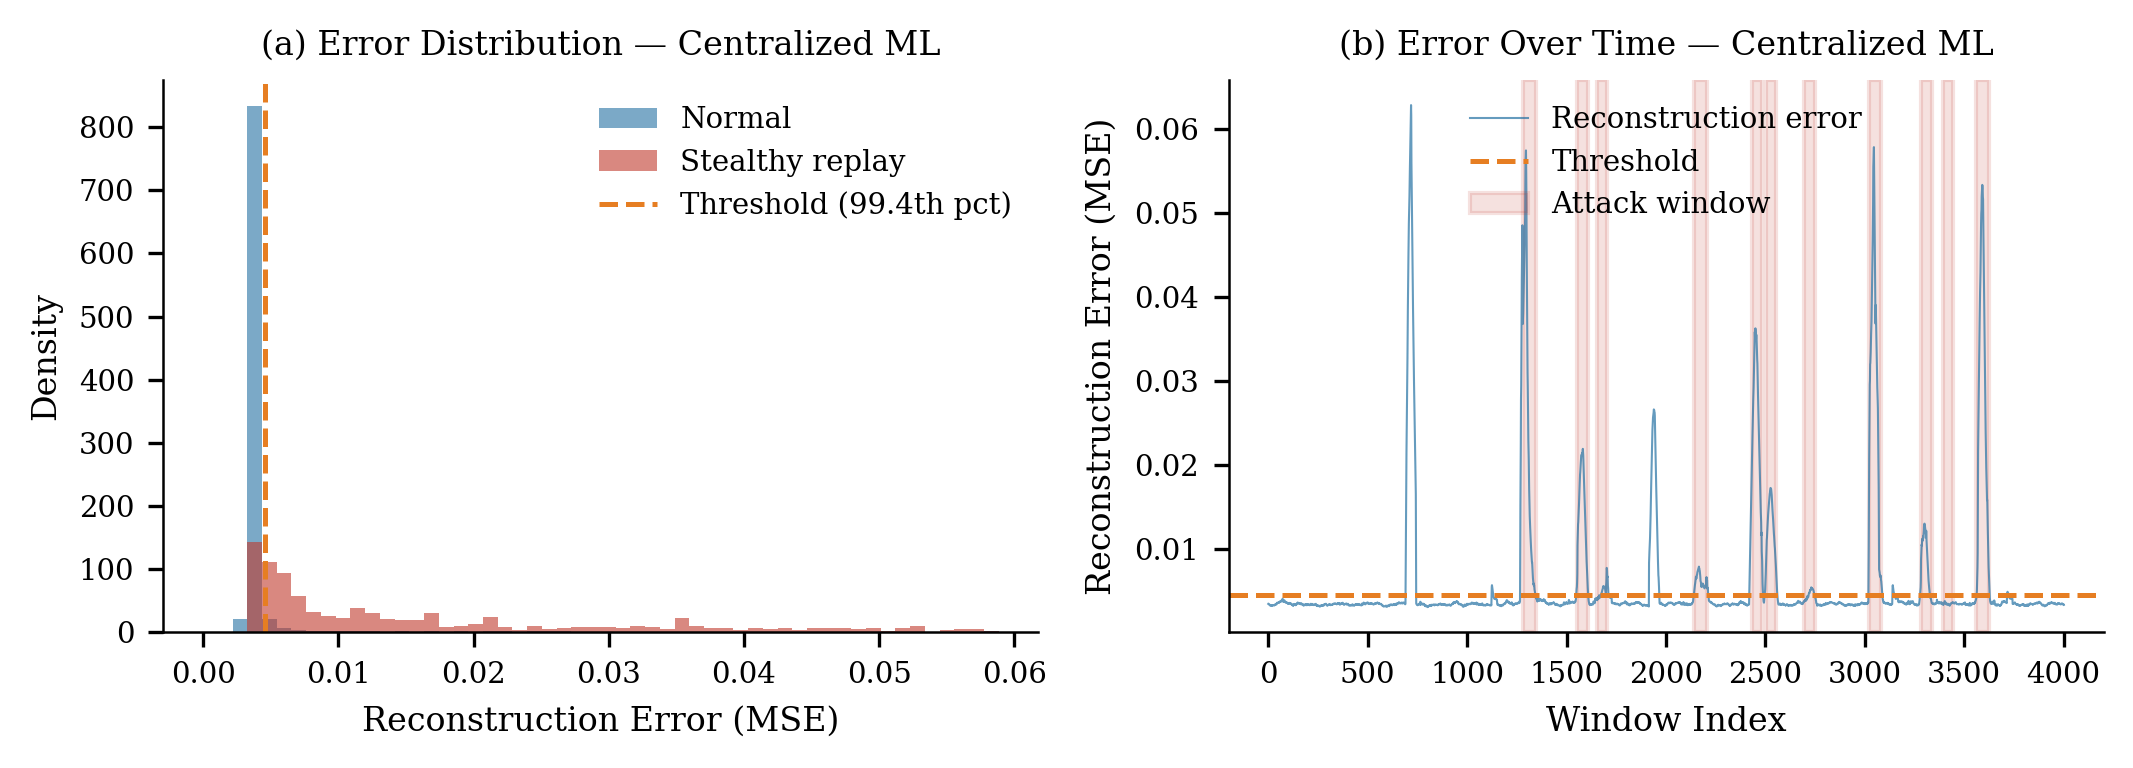

Saved: results/centralized_fig_detection.pdf


In [10]:
normal_errors = test_errors[y_test == 0]
attack_errors = test_errors[y_test == 1]

fig, axes = plt.subplots(1, 2, figsize=(7.16, 2.6))

ax  = axes[0]
cap = np.percentile(test_errors, 99.9)
bins = np.linspace(0, cap, 55)
ax.hist(normal_errors.clip(max=cap), bins=bins, density=True,
        alpha=0.6, color='#2471a3', label='Normal', linewidth=0)
ax.hist(attack_errors.clip(max=cap), bins=bins, density=True,
        alpha=0.6, color='#c0392b', label='Stealthy replay', linewidth=0)
ax.axvline(BEST_THRESHOLD, color='#e67e22', lw=1.2, ls='--',
           label=f'Threshold ({BEST_PCT}th pct)')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('(a) Error Distribution — Centralized ML', fontsize=8)
ax.legend(frameon=False)

ax2 = axes[1]
ax2.plot(test_errors, lw=0.5, color='#2471a3', alpha=0.7,
         label='Reconstruction error')
ax2.axhline(BEST_THRESHOLD, color='#e67e22', lw=1.2, ls='--', label='Threshold')
in_atk, start, first = False, 0, False
for i, lbl in enumerate(y_test):
    if lbl==1 and not in_atk:  start=i; in_atk=True
    elif lbl==0 and in_atk:
        kw = dict(color='#c0392b', alpha=0.15)
        if not first: kw['label']='Attack window'; first=True
        ax2.axvspan(start, i, **kw); in_atk=False
if in_atk: ax2.axvspan(start, len(y_test), color='#c0392b', alpha=0.15)
ax2.legend(frameon=False)
ax2.set_xlabel('Window Index')
ax2.set_ylabel('Reconstruction Error (MSE)')
ax2.set_title('(b) Error Over Time — Centralized ML', fontsize=8)

plt.tight_layout()
plt.savefig(f'results/{MODEL_NAME}_fig_detection.pdf')
plt.savefig(f'results/{MODEL_NAME}_fig_detection.png')
plt.show()
print(f'Saved: results/{MODEL_NAME}_fig_detection.pdf')